<a href="https://colab.research.google.com/github/pranav21122007-hackathon/Salary-Estimation-Using-KNN/blob/main/Salary_Estimation_Using_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving salary.csv to salary.csv


In [ ]:
dataset = pd.read_csv("salary.csv")
dataset

,age,education.num,capital.gain,hours.per.week,income
0,90,9,0,40,<=50K
1,82,9,0,18,<=50K
2,66,10,0,40,<=50K
3,54,4,0,40,<=50K
4,41,10,0,40,<=50K
...,...,...,...,...,...
32556,22,10,0,40,<=50K
32557,27,12,0,38,<=50K
32558,40,9,0,40,>50K
32559,58,9,0,40,<=50K


In [ ]:
print(dataset.shape)

(32561, 5)


In [ ]:
dataset.head(5)

,age,education.num,capital.gain,hours.per.week,income
0,90,9,0,40,<=50K
1,82,9,0,18,<=50K
2,66,10,0,40,<=50K
3,54,4,0,40,<=50K
4,41,10,0,40,<=50K


In [ ]:
income_set = set(dataset['income'])
dataset['income'] = dataset['income'].map({'<=50K' : 0,'>50K' : 1}).astype(int)

In [ ]:
dataset.head(5)

,age,education.num,capital.gain,hours.per.week,income
0,90,9,0,40,0
1,82,9,0,18,0
2,66,10,0,40,0
3,54,4,0,40,0
4,41,10,0,40,0


In [ ]:
X = dataset.iloc[:,:-1].values
X
Y = dataset.iloc[:,-1].values
Y

array([0, 0, 0, ..., 1, 0, 0])

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.20,random_state = 0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

Text(0, 0.5, 'Mean Error')

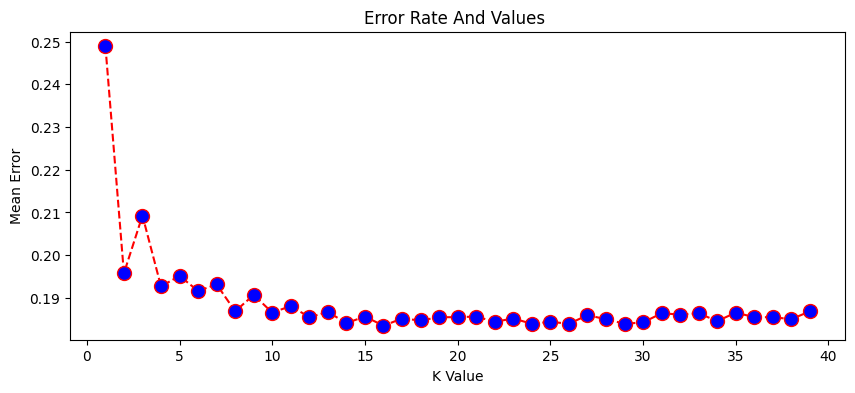

In [ ]:
error = []
from sklearn.neighbors import KNeighborsClassifier
#Calculate error for K values between 1 and 40
for i in range(1,40):
  model = KNeighborsClassifier(n_neighbors = i)
  model.fit(X_train,Y_train)
  pred_i = model.predict(X_test)
  error.append(np.mean(pred_i!=Y_test))
plt.figure(figsize=(10,4))
plt.plot(range(1,40),error,color='red',linestyle='dashed',marker='o',markerfacecolor='blue',markersize=10)
plt.title("Error Rate And Values ")
plt.xlabel("K Value")
plt.ylabel("Mean Error")

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors = 10,metric = 'minkowski',p=2)
model.fit(X_train,Y_train)

KNeighborsClassifier(n_neighbors=10)

In [ ]:
Y_pred = model.predict(X_test)
print(np.concatenate((Y_pred.reshape(len(Y_pred),1),Y_test.reshape(len(Y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm = confusion_matrix(Y_test,Y_pred)
print("Confusion Matrix")
print(cm)
print("Accuracy of the Model : {0}%".format(accuracy_score(Y_test,Y_pred)*100))

Confusion Matrix
[[4700  266]
 [ 949  598]]
Accuracy of the Model : 81.34500230308613%


In [ ]:
age = int(input("Enter Your Age "))
edu = int(input("Enter Your Education "))
cg = int(input("Enter Your Capital Gain "))
wh = int(input("Enter Your Work hours "))
newEmp = [[age,edu,cg,wh]]
result = model.predict(sc.transform(newEmp))
if result == 1:
  print("Employee might get salary >=50K")
else :
  print("Employee might get salary <50K")

Enter Your Age 40
Enter Your Education 9
Enter Your Capital Gain 0
Enter Your Work hours 50
Employee might get salary <50K
